# Segmenting J10c using WaterShed Algorithm

## Saddam Umer

### BAI-22F-026

In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
 
img = cv.imread('/kaggle/input/sadams-practice-images-for-computer-vision/j10c_b.jpeg')

img = cv.putText(img, 'Saddam Umer', (220,70), cv.FONT_HERSHEY_SIMPLEX, 
                   1, (0,255,0), 2, cv.LINE_AA)

img = cv.putText(img, 'BAI-22F-026', (300,380), cv.FONT_HERSHEY_SIMPLEX, 
                   1, (0,255,0), 2, cv.LINE_AA)

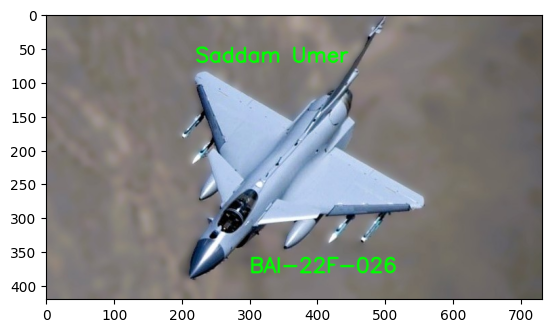

In [2]:
plt.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))

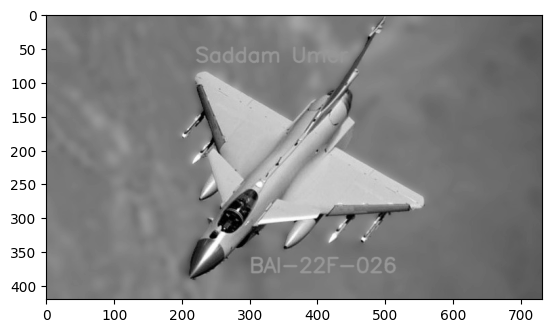

In [3]:
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
plt.imshow(gray,cmap="gray")

In [4]:
# noise removal
kernel = np.ones((3,3),np.uint8)
opening = cv.morphologyEx(thresh,cv.MORPH_OPEN,kernel, iterations = 2)
 
# sure background area
sure_bg = cv.dilate(opening,kernel,iterations=3)
 
# Finding sure foreground area
dist_transform = cv.distanceTransform(opening,cv.DIST_L2,5)
ret, sure_fg = cv.threshold(dist_transform,0.7*dist_transform.max(),255,0)
 
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg,sure_fg)

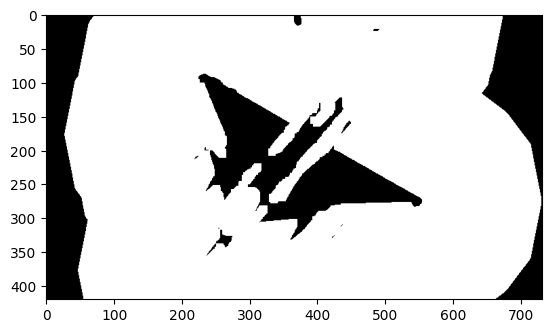

In [5]:
plt.imshow(unknown,cmap="gray")

In [6]:
# Marker labelling
ret, markers = cv.connectedComponents(sure_fg)
 
# Add one to all labels so that sure background is not 0, but 1
markers = markers+1
 
# Now, mark the region of unknown with zero
markers[unknown==255] = 0

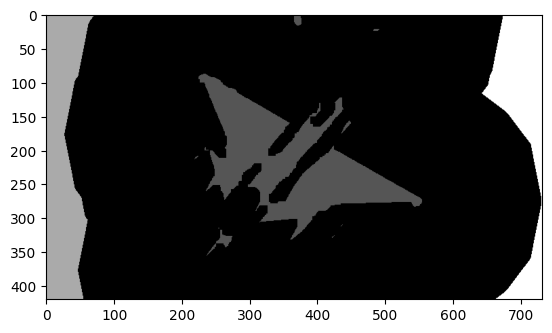

In [7]:
plt.imshow(markers,cmap="gray")

In [8]:
markers = cv.watershed(img,markers)
img[markers == -1] = [255,0,0]

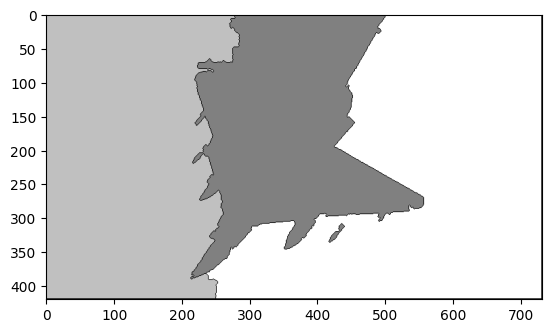

In [9]:
plt.imshow(markers,cmap="gray")